# Stirling engine

This notebook investigates the brownian particle confined inside optical tweezers, undergoing Stirling-like cycles of compressions and expansions. In particular, the particle is placed inside harmonic potential
$$U(t,x) = \frac{1}{2}k(t)x^2$$
and is in contact with reservoir of temperature $T(t)$.

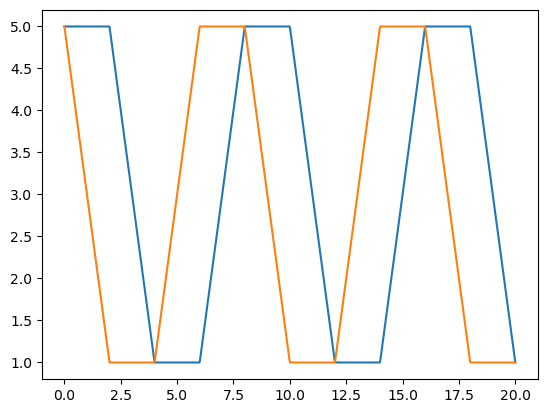

In [94]:
import matplotlib.pyplot as plt
import numpy as np

t0 = 2

def k(t):
    rem = t % t0
    phase = (t // t0) % 4
    
    conditions = [
        phase == 0,
        phase == 1,
        phase == 2,
        phase == 3
    ]

    choices = [
        5,
        5 - 2 * rem,
        1,
        1 + 2 * rem
    ]

    return np.select(conditions, choices, default = np.nan)

def T(t):
    rem = t % t0
    phase = (t // t0) % 4

    conditions = [
        phase == 0,
        phase == 1,
        phase == 2,
        phase == 3
    ]

    choices = [
        5 - 2 * rem,
        1,
        1 + 2 * rem,
        5
    ]

    return np.select(conditions, choices, default = np.nan)

t = np.linspace(0,20,800)
res = np.empty_like(t)
res2 = np.empty_like(t)
for i in range(len(t)):
    res[i] = k(t[i])
    res2[i] = T(t[i])
plt.plot(t,res)
plt.plot(t,res2)

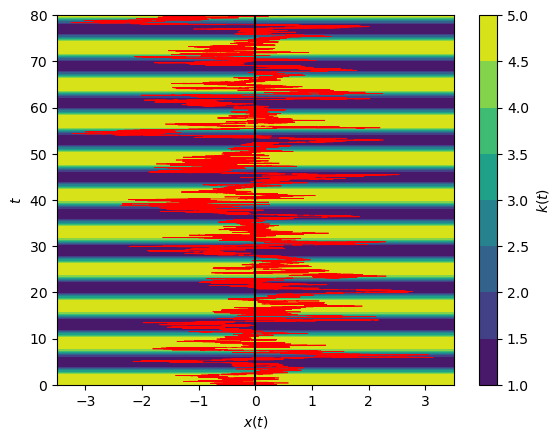

In [7]:
from LSolver import SimulationConfig, overdamped

def beta(t):
    return 1/T(t)
gma = 2.0

cfg = SimulationConfig(
    gamma = gma,
    Fx_func = lambda t,x,y: -k(t)*x,
    Tx_func = lambda t,x,y: T(t),
    t_max = 80.0,
    dt = 0.001
)

fig, ax = plt.subplots(1,1)

[X, Y] = np.meshgrid(np.linspace(-3.5,3.5,150),np.linspace(0,80,150))
Z = k(Y)

cs = ax.contourf(X,Y,Z)

rng = np.random.default_rng(seed = 42)

data = overdamped(cfg, rng = rng)[0]

ax.set(xlabel = r"$x(t)$", ylabel = r"$t$")
ax.plot(data, cfg.t_array, color = "red", linewidth=0.5)
ax.plot([0,0],[0,80], color="black")
fig.colorbar(cs, label = r"$k(t)$")

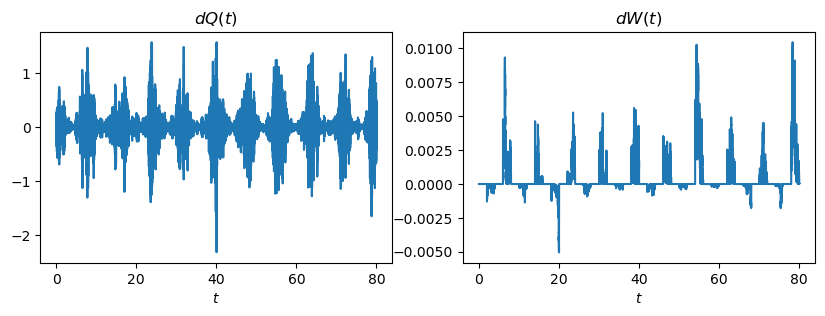

In [8]:
dx = np.diff(data)
dk = np.diff(k(cfg.t_array))

x_mid = 0.5 * (data[:-1] + data[1:])
k_mid = 0.5 * (k(cfg.t_array)[:-1] + k(cfg.t_array)[1:])
t = 0.5 * (cfg.t_array[:-1] + cfg.t_array[1:])

dW = 0.5 * (x_mid**2) * dk
dQ = k_mid * x_mid * dx

fig, [ax1, ax2] = plt.subplots(1,2,figsize=(10,3))
ax1.set(xlabel = r"$t$", title = r"$dQ(t)$")
ax2.set(xlabel = r"$t$", title = r"$dW(t)$")
ax1.plot(t, dQ)
ax2.plot(t, dW)

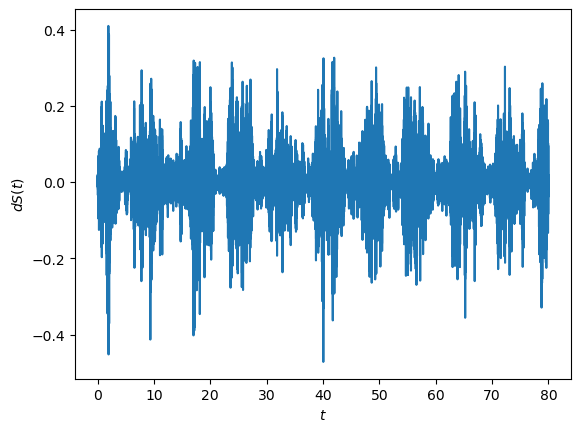

In [9]:
T_mid = 0.5 * (T(cfg.t_array)[:-1] + T(cfg.t_array)[1:])
dS = dQ / T_mid

fig, ax = plt.subplots(1,1)
ax.set(xlabel = r"$t$", ylabel = r"$dS(t)$")
ax.plot(t, dS)

## Measurements of statistical ensemble

Now consider whole ensemble of systems like the above one. In such ensemble, we can calculate fluctuations, deviation and other statistical properties of this Stirling-like process.

In [13]:
from tqdm import tqdm

N = 500

cfg = SimulationConfig(
    gamma = gma,
    Fx_func = lambda t,x,y: -k(t)*x,
    Tx_func = lambda t,x,y: T(t),
    t_max = 56.0,
    dt = 0.01
)

data = np.empty(shape=(N,len(cfg.t_array)))
rng = np.random.default_rng(seed = 42)

for m in tqdm(range(N)):
    data[m] = overdamped(cfg, rng=rng)[0]

print(data)

100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [03:00<00:00,  2.77it/s]

[[ 0.          0.06813681 -0.1673519  ...  0.4714232   0.28788918
   0.33813853]
 [ 0.         -0.09003487 -0.06386205 ... -0.28860021 -0.33072132
  -0.16825199]
 [ 0.          0.28131949  0.42596151 ...  0.20107648 -0.29084886
  -0.19129527]
 ...
 [ 0.          0.06531307  0.25182866 ... -0.11866406 -0.25297491
   0.01964445]
 [ 0.         -0.23835927 -0.22359478 ... -0.68658001 -0.84737339
  -1.16726861]
 [ 0.         -0.17301566  0.05937408 ...  1.57871562  1.68395694
   1.95931303]]


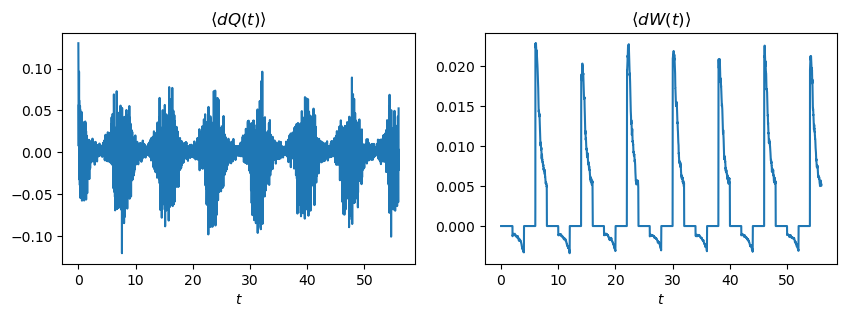

In [24]:
k_mid = 0.5 * (k(cfg.t_array)[:-1] + k(cfg.t_array)[1:])
t = 0.5 * (cfg.t_array[:-1] + cfg.t_array[1:])
x_mid = np.empty(shape=(N,len(k_mid)))

dx = np.empty(shape=(N, len(t)))
dW = np.empty_like(dx)
dQ = np.empty_like(dx)
dk = np.diff(k(cfg.t_array))
for i in range(len(dx)):
    dx[i] = np.diff(data[i])
    x_mid[i] = 0.5 * (data[i,:-1] + data[i,1:])

for i in range(len(dx)):
    dW[i] = 0.5 * (x_mid[i]**2) * dk
    dQ[i] = k_mid * x_mid[i] * dx[i]

dWavg = np.mean(dW, axis = 0)
dQavg = np.mean(dQ, axis = 0)

fig, [ax1, ax2] = plt.subplots(1,2,figsize=(10,3))
ax1.set(xlabel = r"$t$", title = r"$\langle dQ(t)\rangle$")
ax2.set(xlabel = r"$t$", title = r"$\langle dW(t)\rangle$")
ax1.plot(t, dQavg)
ax2.plot(t, dWavg)

2500 799


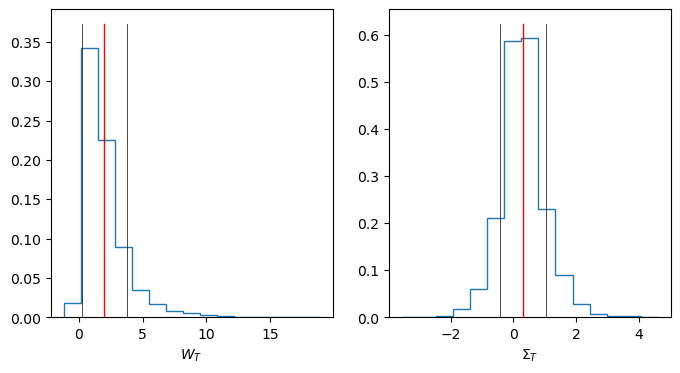

In [117]:
period = 8.0
N_cycles = int(max(cfg.t_array) / period)
steps = len(cfg.t_array) // N_cycles

data_cycles = data.reshape(N, N_cycles, steps)
stable_cycles = data_cycles[:,2:,:].reshape(-1, steps)
cycle_t = cfg.t_array[:steps]

t = 0.5 * (cycle_t[:-1] + cycle_t[1:])
k_mid = 0.5 * (k(cycle_t)[:-1] + k(cycle_t)[1:])
x_mid = np.empty(shape=(N*(N_cycles-2),len(k_mid)))
T_mid = 0.5 * (T(cycle_t)[:-1] + T(cycle_t)[1:])
dx = np.empty_like(x_mid)
dk = np.diff(k(cycle_t))
for i in range(len(dx)):
    dx[i] = np.diff(stable_cycles[i])
    x_mid[i] = 0.5 * (stable_cycles[i,:-1] + stable_cycles[i,1:])

W = np.zeros(shape=(N*(N_cycles - 2)))
Q = np.zeros_like(W)

print(x_mid.shape[0], x_mid.shape[1])

W = np.sum(0.5*(x_mid **2)*dk[np.newaxis, :], axis = 1)
# Entropy from heat dissipated into the reservoir
S = - np.sum(k_mid[np.newaxis, :] * x_mid * dx / T_mid[np.newaxis, :], axis = 1)

fig, [ax1, ax2] = plt.subplots(1,2, figsize=(8,4))

counts, bins = np.histogram(W, density = True, bins = 15)
ax1.stairs(counts, bins)
ax1.set(xlabel=r"$W_T$")
Wmean = np.mean(W)
Wstd = np.std(W)
ax1.plot([Wmean,Wmean],[0,max(counts)+0.03],color = "red", linewidth = 1.0)
ax1.plot([Wmean - Wstd, Wmean - Wstd],[0, max(counts)+0.03], color = "black", linewidth = 0.5)
ax1.plot([Wmean + Wstd, Wmean + Wstd],[0, max(counts)+0.03], color = "black", linewidth = 0.5)

counts, bins = np.histogram(S, density = True, bins = 15)
Smean = np.mean(S)
Sstd = np.std(S)
ax2.stairs(counts, bins)
ax2.set(xlabel=r"$\Sigma_T$")
ax2.plot([Smean,Smean],[0,max(counts)+0.03],color = "red", linewidth = 1.0)
ax2.plot([Smean - Sstd, Smean - Sstd],[0, max(counts)+0.03], color = "black", linewidth = 0.5)
ax2.plot([Smean + Sstd, Smean + Sstd],[0, max(counts)+0.03], color = "black", linewidth = 0.5)

In [120]:
TUR = np.var(W) * np.mean(S) / (np.mean(W))**2

print(TUR)

0.244352090156144
